# 🏥 Modelo Preditivo de Obesidade

**Curso:** Pós-Tech Data Analytics — FIAP  
**Fase:** 4 — Tech Challenge  

---

## Objetivo

Desenvolver uma pipeline completa de Machine Learning para auxiliar equipes médicas
a prever o nível de obesidade de um paciente com base em hábitos alimentares,
atividade física e histórico familiar.

## Estrutura do Notebook

| Seção | Descrição |
|---|---|
| 1. ETL | Carregamento, limpeza e preparação dos dados |
| 2. EDA | Análise exploratória e visualizações |
| 3. Feature Engineering | Criação de novas variáveis |
| 4. Pipeline de ML | Pré-processamento e transformações |
| 5. Modelagem | Treinamento e avaliação dos modelos |
| 6. Deploy | Exportação do modelo final |

---
# 1. ETL — Extração, Transformação e Carga

## 1.1 Importação das Bibliotecas

In [537]:
import pandas as pd

## 1.2 Carregamento dos Dados

In [538]:
obesidade = pd.read_csv('Obesity.csv', sep=',')

## 1.3 Inspeção Inicial

In [539]:
obesidade.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [540]:
obesidade.shape

(2111, 17)

In [541]:
obesidade.isnull().sum()

Gender            0
Age               0
Height            0
Weight            0
family_history    0
FAVC              0
FCVC              0
NCP               0
CAEC              0
SMOKE             0
CH2O              0
SCC               0
FAF               0
TUE               0
CALC              0
MTRANS            0
Obesity           0
dtype: int64

In [542]:
obesidade.nunique()

Gender               2
Age               1402
Height            1574
Weight            1525
family_history       2
FAVC                 2
FCVC               810
NCP                635
CAEC                 4
SMOKE                2
CH2O              1268
SCC                  2
FAF               1190
TUE               1129
CALC                 4
MTRANS               5
Obesity              7
dtype: int64

## 1.4 Verificação dos Valores Categóricos

Inspecionamos os valores únicos das colunas categóricas para entender
a distribuição e identificar possíveis inconsistências antes da limpeza.

In [543]:
obesidade['CAEC'].unique()

array(['Sometimes', 'Frequently', 'Always', 'no'], dtype=object)

In [544]:
obesidade['CALC'].unique()

array(['no', 'Sometimes', 'Frequently', 'Always'], dtype=object)

In [545]:
obesidade['MTRANS'].unique()

array(['Public_Transportation', 'Walking', 'Automobile', 'Motorbike',
       'Bike'], dtype=object)

In [546]:
obesidade['Obesity'].unique()

array(['Normal_Weight', 'Overweight_Level_I', 'Overweight_Level_II',
       'Obesity_Type_I', 'Insufficient_Weight', 'Obesity_Type_II',
       'Obesity_Type_III'], dtype=object)

In [547]:
obesidade['Age'].unique()

array([21.      , 23.      , 27.      , ..., 22.524036, 24.361936,
       23.664709], shape=(1402,))

## 1.5 Limpeza e Normalização

As colunas numéricas `Age`, `NCP`, `FCVC`, `CH2O`, `FAF` e `TUE` possuem valores
decimais causados por ruído na coleta. Arredondamos para o inteiro mais próximo
conforme orientação do dicionário de dados.

In [548]:
obesidade['Age']  = obesidade['Age'].round().astype(int)
obesidade['NCP']  = obesidade['NCP'].round().astype(int)
obesidade['FCVC'] = obesidade['FCVC'].round().astype(int)
obesidade['CH2O'] = obesidade['CH2O'].round().astype(int)
obesidade['FAF']  = obesidade['FAF'].round().astype(int)
obesidade['TUE']  = obesidade['TUE'].round().astype(int)

## 1.6 Validação Pós-Limpeza

In [549]:
obesidade.nunique()

Gender               2
Age                 40
Height            1574
Weight            1525
family_history       2
FAVC                 2
FCVC                 3
NCP                  4
CAEC                 4
SMOKE                2
CH2O                 3
SCC                  2
FAF                  4
TUE                  3
CALC                 4
MTRANS               5
Obesity              7
dtype: int64

In [550]:
obesidade.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21,1.62,64.0,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight
1,Female,21,1.52,56.0,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23,1.80,77.0,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight
3,Male,27,1.80,87.0,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I
4,Male,22,1.78,89.8,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II


In [551]:
# Verificando o resultado final do dataset limpo
obesidade.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   int64  
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   int64  
 7   NCP             2111 non-null   int64  
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   int64  
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   int64  
 13  TUE             2111 non-null   int64  
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 non-null   object 
 16  Obesity         2111 non-null   object 
dtypes: float64(2), int64(6), object(9

---
# 2. EDA — Análise Exploratória dos Dados

## 2.1 Importação das Bibliotecas de Visualização

In [552]:
import matplotlib.pyplot as plt
import seaborn as sns

## 2.2 Matriz de Correlação

Calculamos a correlação entre as variáveis numéricas para identificar
relações relevantes e possíveis candidatos a feature engineering.

<Axes: >

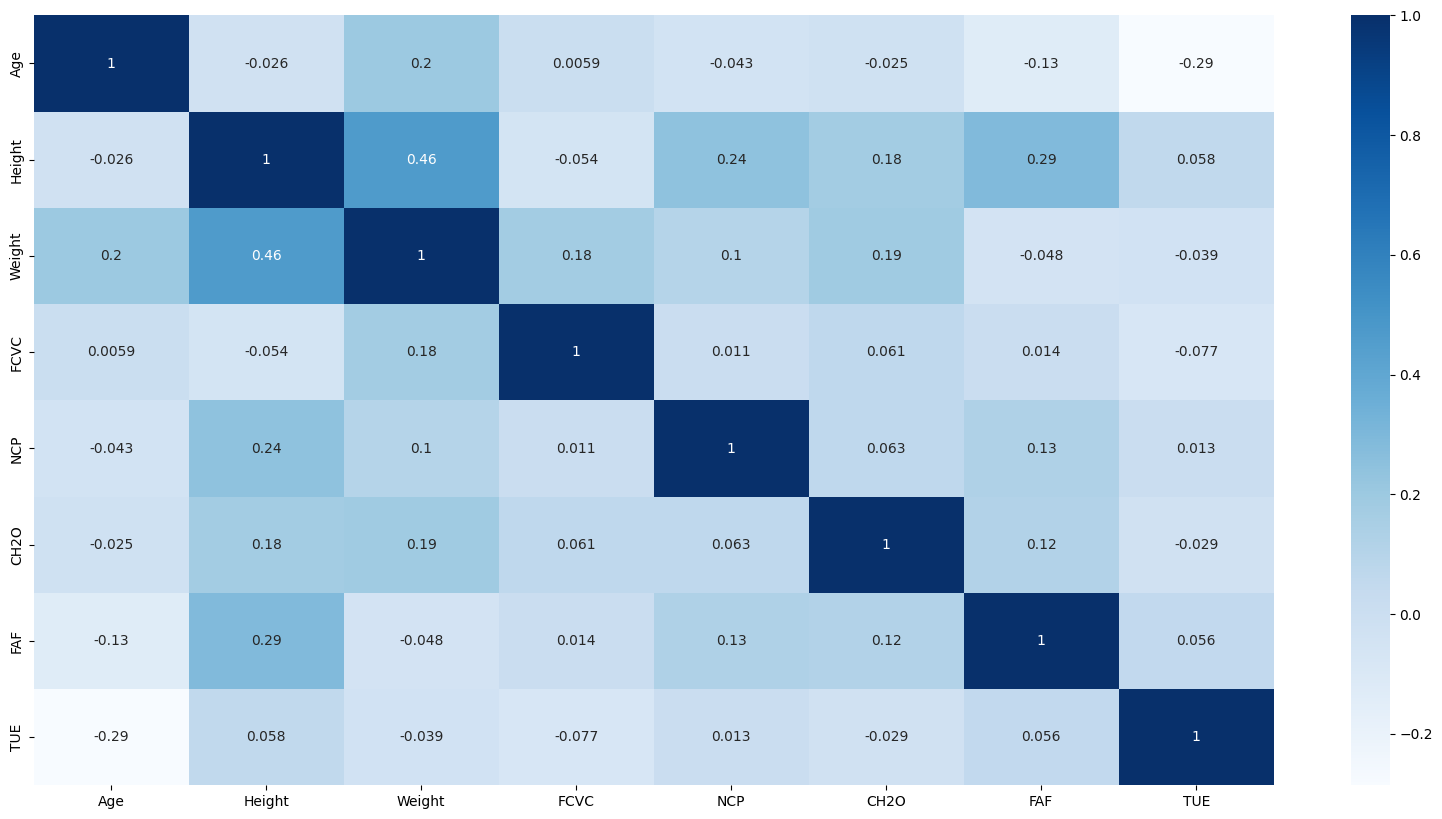

In [553]:
corr = obesidade.corr(numeric_only=True)
plt.figure(figsize = (20,10))
sns.heatmap(corr, cmap="Blues", annot=True)

## 2.3 Seleção de Colunas Relevantes

Reordenamos o DataFrame mantendo apenas as colunas de interesse para o modelo,
conforme definido no dicionário de dados.

In [554]:
obesidade = obesidade[['Age','Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'Gender', 
                       'family_history', 'FAVC', 'SMOKE', 'SCC','CAEC', 'CALC', 
                       'MTRANS', 'Obesity']]

In [555]:
obesidade.head()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender,family_history,FAVC,SMOKE,SCC,CAEC,CALC,MTRANS,Obesity
0,21,1.62,64.0,2,3,2,0,1,Female,yes,no,no,no,Sometimes,no,Public_Transportation,Normal_Weight
1,21,1.52,56.0,3,3,3,3,0,Female,yes,no,yes,yes,Sometimes,Sometimes,Public_Transportation,Normal_Weight
2,23,1.80,77.0,2,3,2,2,1,Male,yes,no,no,no,Sometimes,Frequently,Public_Transportation,Normal_Weight
3,27,1.80,87.0,3,3,2,2,0,Male,no,no,no,no,Sometimes,Frequently,Walking,Overweight_Level_I
4,22,1.78,89.8,2,1,2,0,0,Male,no,no,no,no,Sometimes,Sometimes,Public_Transportation,Overweight_Level_II


## 2.4 Estatísticas Descritivas

In [556]:
obesidade[['Age']].describe()

,Age
count,2111.000000
mean,24.315964
std,6.357078
min,14.000000
25%,20.000000
50%,23.000000
75%,26.000000
max,61.000000


In [557]:
obesidade['MTRANS'].value_counts(normalize = True) * 100

MTRANS
Public_Transportation    74.846045
Automobile               21.648508
Walking                   2.652771
Motorbike                 0.521080
Bike                      0.331596
Name: proportion, dtype: float64

In [558]:
obesidade['CAEC'].value_counts(normalize = True) * 100

CAEC
Sometimes     83.609664
Frequently    11.463761
Always         2.510658
no             2.415917
Name: proportion, dtype: float64

In [559]:
obesidade['CALC'].value_counts(normalize = True) * 100

CALC
Sometimes     66.366651
no            30.270014
Frequently     3.315964
Always         0.047371
Name: proportion, dtype: float64

In [560]:
obesidade['Obesity'].value_counts(normalize = True) * 100

Obesity
Obesity_Type_I         16.627191
Obesity_Type_III       15.348176
Obesity_Type_II        14.069162
Overweight_Level_I     13.737565
Overweight_Level_II    13.737565
Normal_Weight          13.595452
Insufficient_Weight    12.884889
Name: proportion, dtype: float64

## 2.5 Distribuição da Variável Idade

Verificamos a distribuição da idade com histograma e boxplot
para identificar a faixa etária predominante e possíveis outliers.

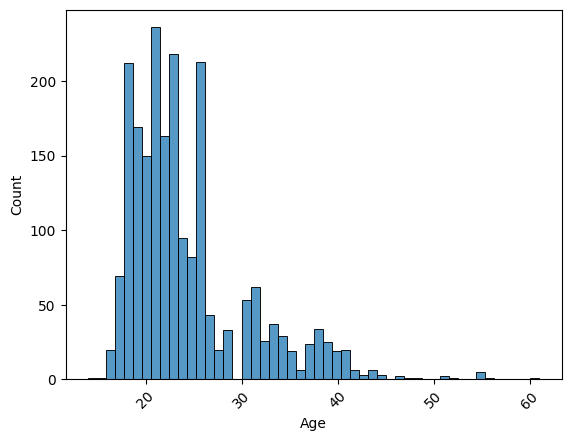

In [561]:
sns.histplot(data=obesidade, x='Age', bins=50) 
plt.xticks(rotation=45)
plt.show()

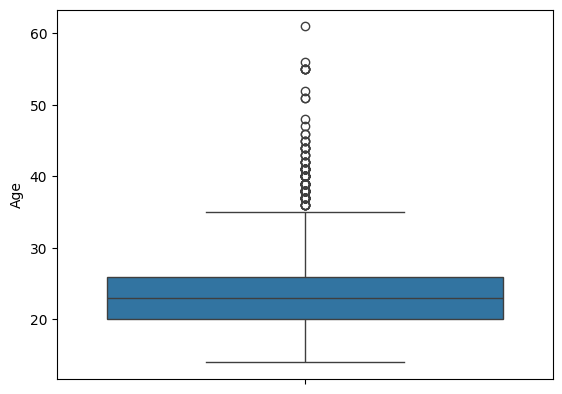

In [562]:
sns.boxplot(data=obesidade, y='Age') 
plt.xticks(rotation=45)
plt.show()

## 2.6 Visualizações Interativas

In [563]:
import plotly.express as px

### Paleta de Cores Padronizada

Utilizamos uma paleta sequencial em tons de azul para representar a progressão
dos níveis de obesidade — do mais claro (menor gravidade) ao mais escuro (maior gravidade).

In [564]:
# =======================================================
# PADRONIZAÇÃO DE CORES (Paleta Sequencial em Tons de Azul)
# =======================================================
mapa_cores = {
    'Insufficient_Weight': '#c6dbef',  # azul claro
    'Normal_Weight':        '#9ecae1',
    'Overweight_Level_I':   '#6baed6',
    'Overweight_Level_II':  '#4292c6',
    'Obesity_Type_I':       '#2171b5',
    'Obesity_Type_II':      '#08519c',
    'Obesity_Type_III':     '#08306b'   # azul escuro
}

ordem_peso = [
    'Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I', 
    'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III'
]

### Distribuição dos Níveis de Obesidade (%)

In [565]:
# =======================================================
# GRÁFICO Distribuição de Obesidade em Percentual
# =======================================================
# Calculando a porcentagem real antes de plotar
df_pct = obesidade['Obesity'].value_counts(normalize=True).reset_index()
df_pct.columns = ['Obesity', 'Percentual']
df_pct['Percentual'] = df_pct['Percentual'] * 100

fig_dist = px.bar(
    df_pct, 
    x='Obesity', 
    y='Percentual', 
    color='Obesity',
    color_discrete_map=mapa_cores,
    category_orders={'Obesity': ordem_peso},
    text_auto='.1f',
    title='Distribuição dos Níveis de Obesidade (%)'
)
fig_dist.update_layout(showlegend=False, xaxis_title='Categoria de Peso', yaxis_title='Percentual (%)')
fig_dist.show()

### Faixa de Idade por Nível de Peso

In [566]:
# =======================================================
# GRÁFICO Distribuição de Idade por Nível (Boxplot)
# =======================================================
fig_age = px.box(
    obesidade, 
    x='Obesity', 
    y='Age', 
    color='Obesity',
    color_discrete_map=mapa_cores,
    category_orders={'Obesity': ordem_peso},
    title='Faixa de Idade por Nível de Peso'
)
fig_age.update_layout(xaxis_title='Categoria de Peso', yaxis_title='Idade')
fig_age.show()

### Explorador: Altura vs Peso

In [567]:
# =======================================================
# GRÁFICO Explorador de IMC (Altura vs Peso)
# Paleta divergente para maximizar contraste entre categorias
# =======================================================
cores_scatter = {
    'Insufficient_Weight': '#4575b4',  # azul
    'Normal_Weight':        '#91bfdb',
    'Overweight_Level_I':   '#fee090',  # amarelo
    'Overweight_Level_II':  '#fc8d59',  # laranja
    'Obesity_Type_I':       '#d73027',  # vermelho
    'Obesity_Type_II':      '#a50026',
    'Obesity_Type_III':     '#67001f'   # vermelho escuro
}

fig_imc = px.scatter(
    obesidade, 
    x='Height', 
    y='Weight', 
    color='Obesity',
    color_discrete_map=cores_scatter,
    category_orders={'Obesity': ordem_peso},
    hover_data=['Age', 'Gender'], 
    title='Explorador: Altura vs Peso'
)
fig_imc.show()

### Consumo de Alimentos Calóricos por Nível de Peso

In [568]:
# =======================================================
# GRÁFICO Consumo Frequente de Alta Caloria (FAVC) - Agrupado por Peso
# =======================================================
fig_favc = px.histogram(
    obesidade, 
    x='Obesity', 
    color='FAVC',
    category_orders={'Obesity': ordem_peso, 'FAVC': ['yes', 'no']},
    barmode='group',
    text_auto=True,
    color_discrete_map={'yes': '#08306b', 'no': '#9ecae1'}, 
    title='Consumo Frequente de Alta Caloria (FAVC) por Nível de Peso'
)
fig_favc.update_layout(xaxis_title='Categoria de Peso', yaxis_title='Quantidade de Pessoas')
fig_favc.show()

### Distribuição do IMC na População

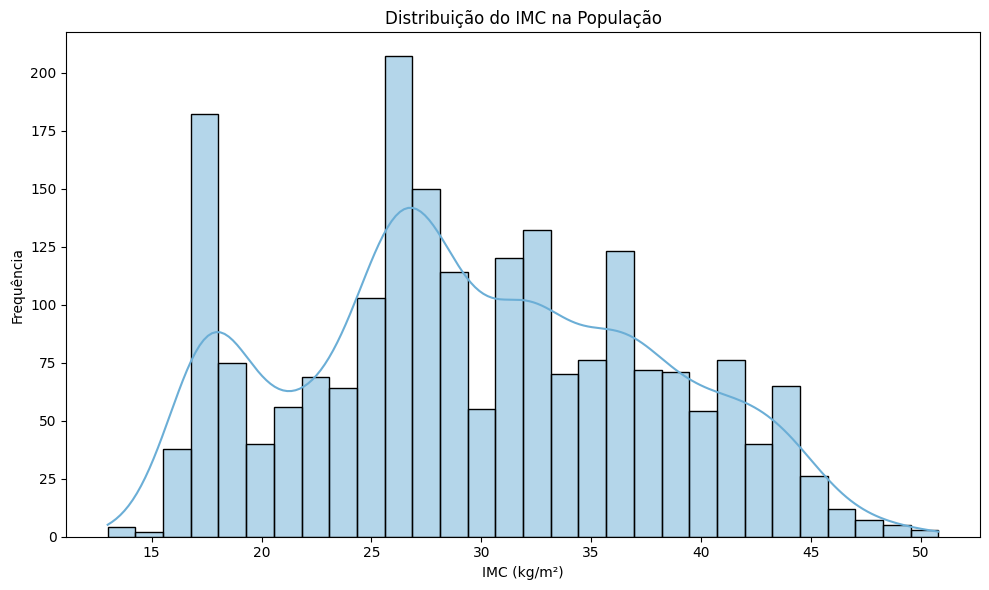

In [569]:
# Criando a coluna de IMC (Peso / Altura²) para análise exploratória
obesidade['IMC'] = obesidade['Weight'] / (obesidade['Height'] ** 2)

# =======================================================
# Distribuição Geral do IMC — Histograma com Curva KDE
# =======================================================
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(obesidade['IMC'], bins=30, kde=True, color='#6baed6', edgecolor='black', ax=ax)
ax.set_xlabel('IMC (kg/m²)')
ax.set_ylabel('Frequência')
ax.set_title('Distribuição do IMC na População')
plt.tight_layout()
plt.show()

In [570]:
obesidade.drop('IMC', axis=1, inplace=True)

### Proporção de Níveis de Peso por Gênero (100% Empilhado)

In [571]:
# =======================================================
# Distribuição de Gênero pela Obesidade (100% Empilhado)
# =======================================================
# Calculando a proporção interna (100%) por gênero
df_gender = obesidade.groupby(['Gender', 'Obesity']).size().reset_index(name='Count')
df_gender['Percentual'] = df_gender.groupby('Gender')['Count'].transform(lambda x: (x / x.sum()) * 100)

fig_gender = px.bar(
    df_gender, 
    x='Gender', 
    y='Percentual', 
    color='Obesity', 
    color_discrete_map=mapa_cores, 
    category_orders={'Obesity': ordem_peso},
    text_auto='.1f',
    title='Proporção de Níveis de Peso por Gênero (100% Empilhado)'
)
fig_gender.update_layout(
    xaxis_title='Gênero', 
    yaxis_title='Percentual (%)',
    barmode='stack'
)
fig_gender.show()

---
# 3. Exportação do Dataset Limpo

Exportamos o dataset após a limpeza e antes de qualquer transformação para o modelo.
Este arquivo é utilizado pelo dashboard analítico no Streamlit.

In [572]:
# Garantindo que obesidade é uma cópia independente antes de exportar
obesidade = obesidade.copy()

In [573]:
df = obesidade.copy()

In [574]:
df.to_csv('obesidade_clean.csv', index=False)

---
# 4. Feature Engineering

Criamos novas variáveis derivadas dos dados originais para enriquecer
a capacidade preditiva do modelo.

| Feature | Descrição |
|---|---|
| `qualidade_dieta` | Score combinando frequência de vegetais, refeições e alimentos calóricos |
| `risco_genetico_habito` | Interação entre histórico familiar e consumo calórico |
| `alcool_sedentario` | Interação entre consumo de álcool e tempo em dispositivos |

## 4.1 Encoding do Target

Convertemos a variável alvo `Obesity` para valores numéricos ordinais,
respeitando a ordem clínica de gravidade.

In [575]:
mapa_obesidade = {
    'Insufficient_Weight': 0,
    'Normal_Weight': 1,
    'Overweight_Level_I': 2,
    'Overweight_Level_II': 3,
    'Obesity_Type_I': 4,
    'Obesity_Type_II': 5,
    'Obesity_Type_III': 6
}
df['Obesity'] = df['Obesity'].map(mapa_obesidade)

CLASSES = list(mapa_obesidade.keys())  # mantém a ordem correta

## 4.2 Criação das Novas Features

In [576]:
# Score de qualidade da dieta: quanto maior o valor, melhor a alimentação
df['qualidade_dieta'] = df['FCVC'] * df['NCP'] - (df['FAVC'] == 'yes').astype(int)

# Risco combinado: histórico familiar positivo + consumo frequente de calóricos
df['risco_genetico_habito'] = (df['family_history'] == 'yes').astype(int) * (df['FAVC'] == 'yes').astype(int)

# Interação entre sedentarismo tecnológico e consumo de álcool
df['alcool_sedentario'] = df['CALC'].map({'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}) * df['TUE']

---
# 5. Pipeline de Machine Learning

Construímos uma pipeline de pré-processamento que encapsula todas as
transformações necessárias, garantindo que o mesmo fluxo seja aplicado
no treino, no teste e na predição em produção.

## 5.1 Divisão Treino/Teste

In [577]:
from sklearn.model_selection import train_test_split

In [578]:
SEED = 42

In [579]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=SEED)
print(f'Treino: {train_df.shape} | Teste: {test_df.shape}')

Treino: (1688, 20) | Teste: (423, 20)


In [580]:
# Cópias de segurança dos splits originais antes da pipeline
train_df_copy = train_df.copy()
test_df_copy  = test_df.copy()

In [581]:
train_df.head()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender,family_history,FAVC,SMOKE,SCC,CAEC,CALC,MTRANS,Obesity,qualidade_dieta,risco_genetico_habito,alcool_sedentario
162,21,1.630000,60.000000,3,3,2,2,0,Female,yes,yes,yes,no,Always,Sometimes,Public_Transportation,1,8,1,0
2001,21,1.752531,133.618706,3,3,3,1,1,Female,yes,yes,no,no,Sometimes,Sometimes,Public_Transportation,6,8,1,1
1435,23,1.661715,82.595793,1,1,3,0,2,Female,yes,yes,no,no,Sometimes,Sometimes,Public_Transportation,4,0,1,2
649,22,1.588046,44.236067,3,2,3,1,0,Female,no,no,no,no,Frequently,no,Public_Transportation,0,6,0,0
1280,26,1.811602,106.042142,3,3,3,2,1,Male,yes,yes,no,no,Sometimes,Sometimes,Public_Transportation,4,8,1,1


## 5.2 Transformadores Customizados

Os transformadores são importados do módulo `utils.py` para garantir
que o joblib serializado encontre as classes corretamente tanto no
notebook quanto na aplicação Streamlit.

In [582]:
from sklearn.base import BaseEstimator, TransformerMixin 
from utils import DropFeatures, MinMax, CustomOrdinalEncoder, CustomOneHotEncoder

## 5.3 Construção da Pipeline

A pipeline executa as seguintes etapas em sequência:
1. **DropFeatures** — remove `Weight` e `Height` (evita data leakage via IMC)
2. **CustomOrdinalEncoder (binário)** — encoda variáveis binárias (`Gender`, `FAVC`, etc.)
3. **CustomOrdinalEncoder (frequência)** — encoda `CAEC` e `CALC` com ordem semântica correta
4. **CustomOneHotEncoder** — encoda `MTRANS` com one-hot
5. **MinMax** — normaliza todas as variáveis numéricas para o intervalo [0, 1]

In [583]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('remover_colunas', DropFeatures(feature_to_drop=['Weight'])),
    
    # Variáveis binárias: Male/Female, yes/no — sem tradução prévia
    ('ordinal_binario', CustomOrdinalEncoder(
        columns=['Gender', 'family_history', 'FAVC', 'SMOKE', 'SCC']
    )),
    
    # Variáveis de frequência: ordem semântica no < Sometimes < Frequently < Always
    ('ordinal_freq', CustomOrdinalEncoder(
        columns=['CAEC', 'CALC'],
        categories=[
            ['no', 'Sometimes', 'Frequently', 'Always'],
            ['no', 'Sometimes', 'Frequently', 'Always']
        ]
    )),
    
    ('one_hot', CustomOneHotEncoder(columns=['MTRANS'])),
    ('scaler',  MinMax(min_max_scaler=['Age', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE',
                                        'alcool_sedentario',
                                       'qualidade_dieta', 'risco_genetico_habito']))
])

## 5.4 Aplicação da Pipeline

In [584]:
# Fit + transform nos dados de treino
train = pipeline.fit_transform(train_df)

In [585]:
train.head()

,Age,Height,FCVC,NCP,CH2O,FAF,TUE,Gender,family_history,FAVC,...,CALC,Obesity,qualidade_dieta,risco_genetico_habito,alcool_sedentario,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
162,0.148936,1.630000,1.0,0.666667,0.5,0.666667,0.0,0.0,1.0,1.0,...,1.0,1,0.666667,1.0,0.000000,0.0,0.0,0.0,1.0,0.0
2001,0.148936,1.752531,1.0,0.666667,1.0,0.333333,0.5,0.0,1.0,1.0,...,1.0,6,0.666667,1.0,0.166667,0.0,0.0,0.0,1.0,0.0
1435,0.191489,1.661715,0.0,0.000000,1.0,0.000000,1.0,0.0,1.0,1.0,...,1.0,4,0.000000,1.0,0.333333,0.0,0.0,0.0,1.0,0.0
649,0.170213,1.588046,1.0,0.333333,1.0,0.333333,0.0,0.0,0.0,0.0,...,0.0,0,0.500000,0.0,0.000000,0.0,0.0,0.0,1.0,0.0
1280,0.255319,1.811602,1.0,0.666667,1.0,0.666667,0.5,1.0,1.0,1.0,...,1.0,4,0.666667,1.0,0.166667,0.0,0.0,0.0,1.0,0.0


In [586]:
# Separando features e target — treino
X_train, y_train = train.loc[:, train.columns != 'Obesity'], train['Obesity']

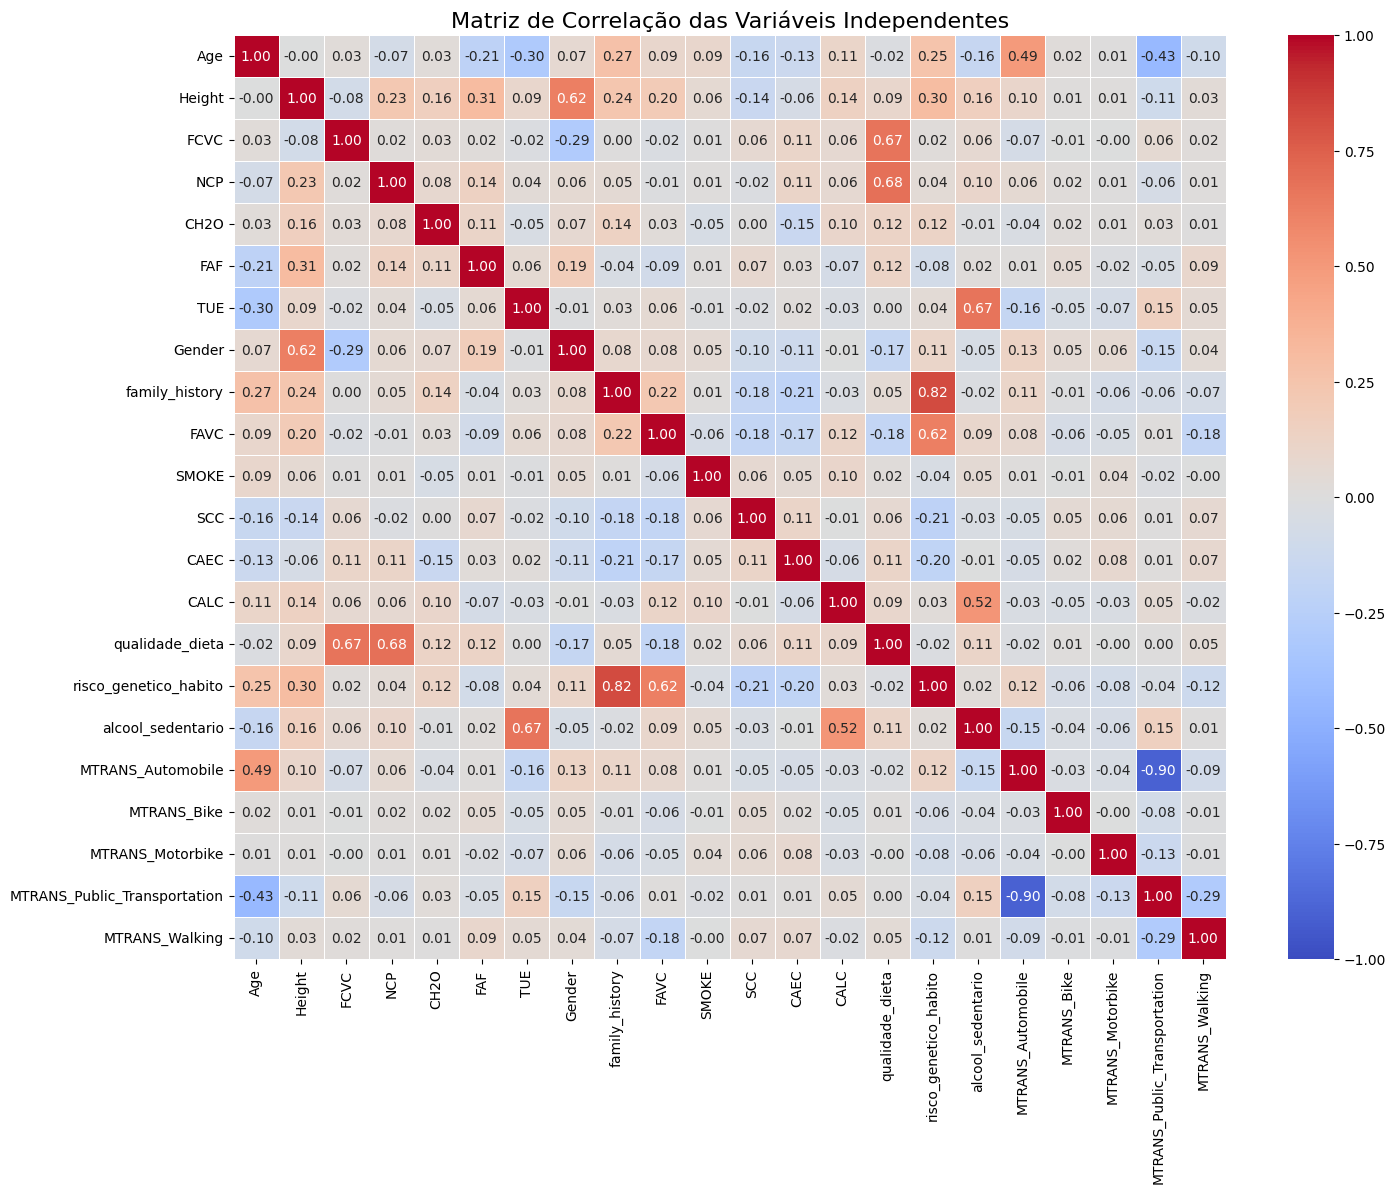

In [587]:
# Calcula a matriz de correlação usando o método Spearman
# (Se X_train tiver variáveis categóricas em texto, faça apenas com as numéricas)
matriz_corr = X_train.select_dtypes(include=['float64', 'int64']).corr(method='spearman')

# Configura o tamanho do gráfico
plt.figure(figsize=(16, 12))

# Plota o mapa de calor (Heatmap)
sns.heatmap(matriz_corr, 
            annot=True,          # Mostra os números dentro dos quadrados
            fmt=".2f",           # Arredonda para 2 casas decimais
            cmap="coolwarm",     # Cores: vermelho = correlação positiva, azul = negativa
            vmin=-1, vmax=1,     # Limites da correlação (-1 a 1)
            linewidths=0.5)

plt.title("Matriz de Correlação das Variáveis Independentes", fontsize=16)
plt.show()

In [588]:
# Apenas transform nos dados de teste (sem re-fit para evitar leakage)
test = pipeline.transform(test_df)

In [589]:
test.head()

,Age,Height,FCVC,NCP,CH2O,FAF,TUE,Gender,family_history,FAVC,...,CALC,Obesity,qualidade_dieta,risco_genetico_habito,alcool_sedentario,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
544,0.127660,1.755978,0.5,1.000000,0.5,1.000000,1.0,0.0,1.0,1.0,...,0.0,0,0.583333,1.0,0.000000,0.0,0.0,0.0,1.0,0.0
1987,0.255319,1.624950,1.0,0.666667,1.0,0.000000,0.0,0.0,1.0,1.0,...,1.0,6,0.666667,1.0,0.000000,0.0,0.0,0.0,1.0,0.0
420,0.085106,1.850000,1.0,1.000000,0.5,0.666667,0.0,1.0,1.0,1.0,...,1.0,0,0.916667,1.0,0.000000,1.0,0.0,0.0,0.0,0.0
527,0.148936,1.520000,1.0,0.000000,0.0,0.000000,0.0,0.0,0.0,1.0,...,1.0,0,0.166667,0.0,0.000000,0.0,0.0,0.0,1.0,0.0
196,0.170213,1.750000,0.5,0.666667,0.5,0.333333,1.0,1.0,1.0,0.0,...,1.0,1,0.500000,0.0,0.333333,0.0,1.0,0.0,0.0,0.0


In [590]:
# Separando features e target — teste
X_test, y_test = test.loc[:, test.columns != 'Obesity'], test['Obesity']

---
# 6. Modelagem

Treinamos e avaliamos múltiplos algoritmos de classificação multiclasse.
A métrica principal é a **acurácia**, com AUC como métrica complementar.
O requisito mínimo do projeto é acurácia acima de **75%**.

## 6.1 Importações e Função de Avaliação

In [591]:
from sklearn import metrics
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix 
)
import warnings
warnings.filterwarnings('ignore')

In [592]:
SEED = 42

CLASSES = [
    'Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I',
    'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III'
]

def roda_modelo(modelo):
    """
    Treina e avalia um modelo de classificação multiclasse.

    Parâmetros
    ----------
    modelo : estimador sklearn
        Modelo a ser treinado e avaliado.

    Saída
    -----
    Imprime AUC weighted OvR, matriz de confusão normalizada
    e classification report com precisão, recall e F1 por classe.
    """
    modelo.fit(X_train, y_train)

    predicao   = modelo.predict(X_test)
    prob_predic = modelo.predict_proba(X_test)

    print(f'\n{"-"*30} Resultados {modelo} {"-"*30}\n')

    # AUC multiclasse — one-vs-rest com média ponderada
    auc = roc_auc_score(y_test, prob_predic, multi_class='ovr', average='weighted')
    print(f'AUC (weighted OvR): {auc:.4f}')

    # Matriz de confusão normalizada
    print('\nConfusion Matrix\n')
    fig, ax = plt.subplots(figsize=(10, 8))
    ConfusionMatrixDisplay.from_estimator(
        modelo, X_test, y_test,
        normalize='true',
        display_labels=CLASSES,
        ax=ax,
        cmap=plt.cm.Blues,
        xticks_rotation=45
    )
    ax.set_title('Matriz de Confusão Normalizada', fontsize=14, fontweight='bold')
    ax.set_xlabel('Label Predita', fontsize=12)
    ax.set_ylabel('Label Verdadeira', fontsize=12)
    plt.tight_layout()
    plt.grid(False)
    plt.show()

    # Relatório completo por classe
    print('\nClassification Report')
    print(classification_report(y_test, predicao, target_names=CLASSES, zero_division=0))

## 6.2 Modelos Base

### Regressão Logística

In [593]:
from sklearn.linear_model import LogisticRegression
modelo_logistico = LogisticRegression()


------------------------------ Resultados LogisticRegression() ------------------------------

AUC (weighted OvR): 0.8757

Confusion Matrix



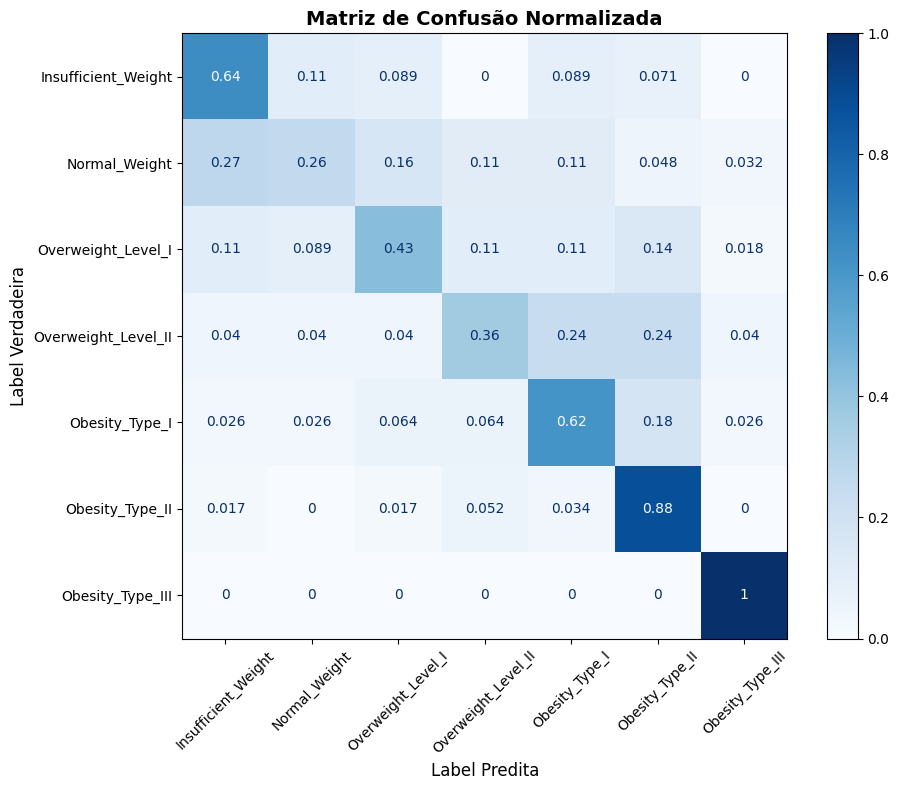


Classification Report
                     precision    recall  f1-score   support

Insufficient_Weight       0.56      0.64      0.60        56
      Normal_Weight       0.52      0.26      0.34        62
 Overweight_Level_I       0.51      0.43      0.47        56
Overweight_Level_II       0.46      0.36      0.40        50
     Obesity_Type_I       0.60      0.62      0.61        78
    Obesity_Type_II       0.55      0.88      0.68        58
   Obesity_Type_III       0.90      1.00      0.95        63

           accuracy                           0.61       423
          macro avg       0.59      0.60      0.58       423
       weighted avg       0.59      0.61      0.59       423



In [594]:
roda_modelo(modelo_logistico)

### Árvore de Decisão

In [595]:
from sklearn.tree import DecisionTreeClassifier
modelo_tree = DecisionTreeClassifier()


------------------------------ Resultados DecisionTreeClassifier() ------------------------------

AUC (weighted OvR): 0.8387

Confusion Matrix



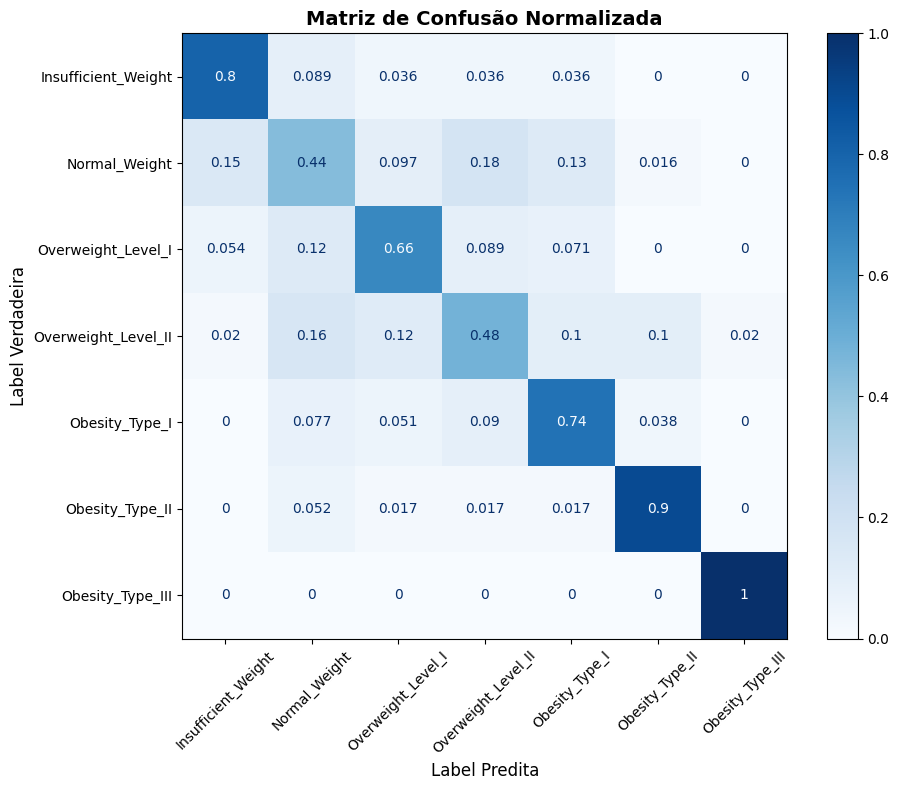


Classification Report
                     precision    recall  f1-score   support

Insufficient_Weight       0.78      0.80      0.79        56
      Normal_Weight       0.48      0.44      0.46        62
 Overweight_Level_I       0.66      0.66      0.66        56
Overweight_Level_II       0.48      0.48      0.48        50
     Obesity_Type_I       0.74      0.74      0.74        78
    Obesity_Type_II       0.85      0.90      0.87        58
   Obesity_Type_III       0.98      1.00      0.99        63

           accuracy                           0.72       423
          macro avg       0.71      0.72      0.71       423
       weighted avg       0.72      0.72      0.72       423



In [596]:
roda_modelo(modelo_tree)

### Random Forest

In [597]:
from sklearn.ensemble import RandomForestClassifier
modelo_forest = RandomForestClassifier()


------------------------------ Resultados RandomForestClassifier() ------------------------------

AUC (weighted OvR): 0.9738

Confusion Matrix



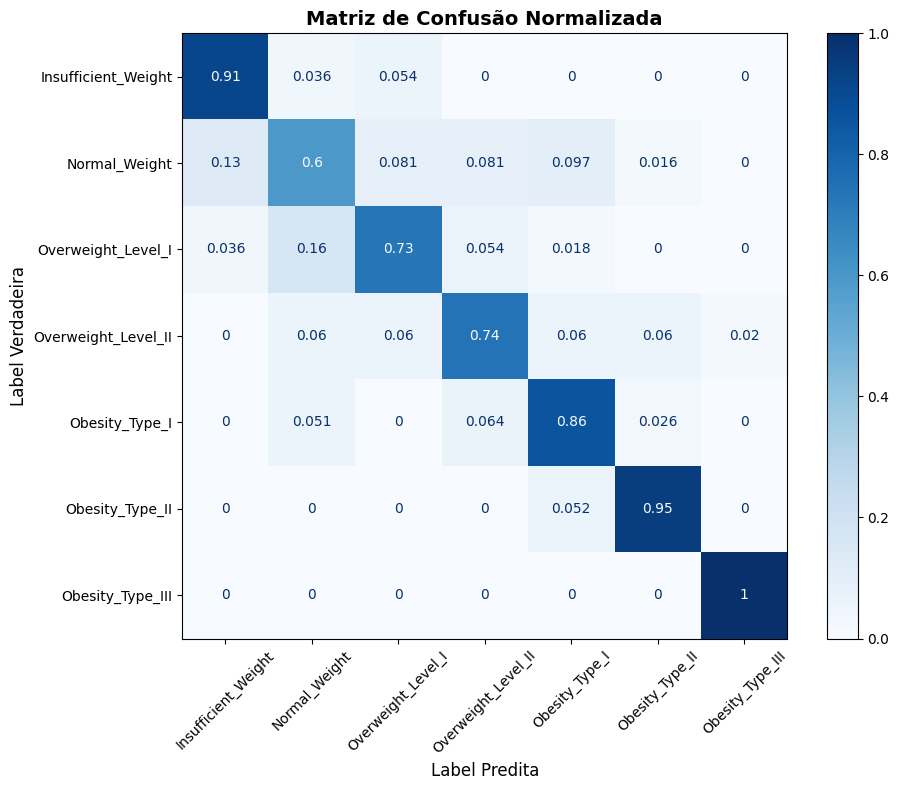


Classification Report
                     precision    recall  f1-score   support

Insufficient_Weight       0.84      0.91      0.87        56
      Normal_Weight       0.67      0.60      0.63        62
 Overweight_Level_I       0.79      0.73      0.76        56
Overweight_Level_II       0.74      0.74      0.74        50
     Obesity_Type_I       0.84      0.86      0.85        78
    Obesity_Type_II       0.90      0.95      0.92        58
   Obesity_Type_III       0.98      1.00      0.99        63

           accuracy                           0.83       423
          macro avg       0.82      0.83      0.82       423
       weighted avg       0.83      0.83      0.83       423



In [598]:
roda_modelo(modelo_forest)

### Gradient Boosting

In [599]:
from sklearn.ensemble import GradientBoostingClassifier
modelo_xgb = GradientBoostingClassifier()


------------------------------ Resultados GradientBoostingClassifier() ------------------------------

AUC (weighted OvR): 0.9617

Confusion Matrix



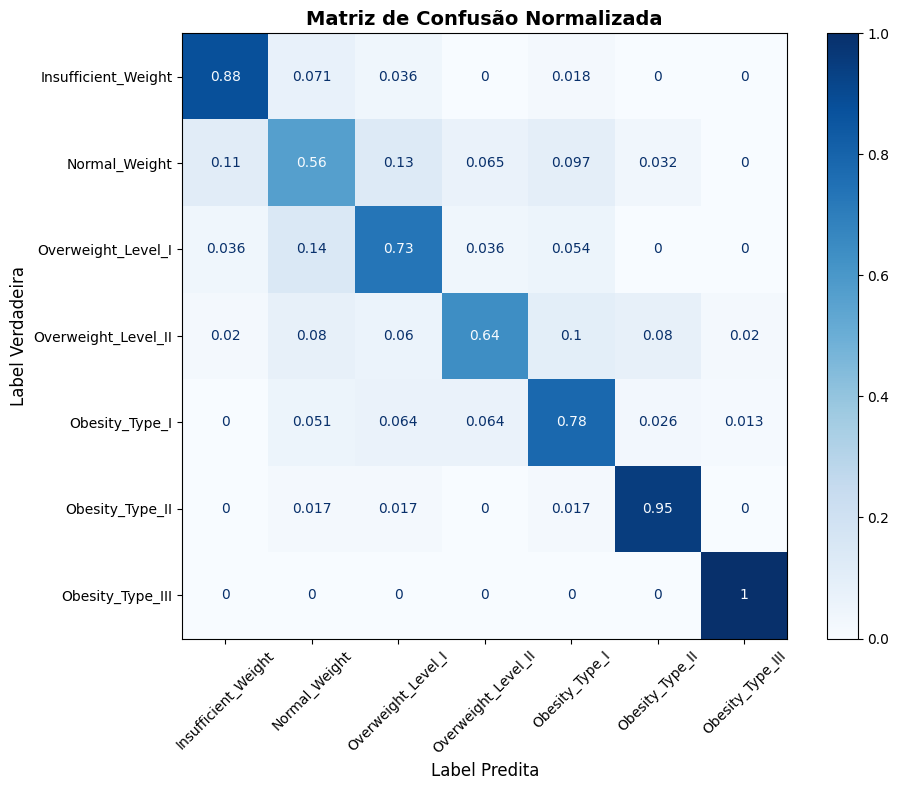


Classification Report
                     precision    recall  f1-score   support

Insufficient_Weight       0.83      0.88      0.85        56
      Normal_Weight       0.62      0.56      0.59        62
 Overweight_Level_I       0.68      0.73      0.71        56
Overweight_Level_II       0.74      0.64      0.69        50
     Obesity_Type_I       0.79      0.78      0.79        78
    Obesity_Type_II       0.87      0.95      0.91        58
   Obesity_Type_III       0.97      1.00      0.98        63

           accuracy                           0.79       423
          macro avg       0.79      0.79      0.79       423
       weighted avg       0.79      0.79      0.79       423



In [600]:
roda_modelo(modelo_xgb)

### LightGBM

In [601]:
from lightgbm import LGBMClassifier
modelo_lgbm = LGBMClassifier()


------------------------------ Resultados LGBMClassifier() ------------------------------

AUC (weighted OvR): 0.9710

Confusion Matrix



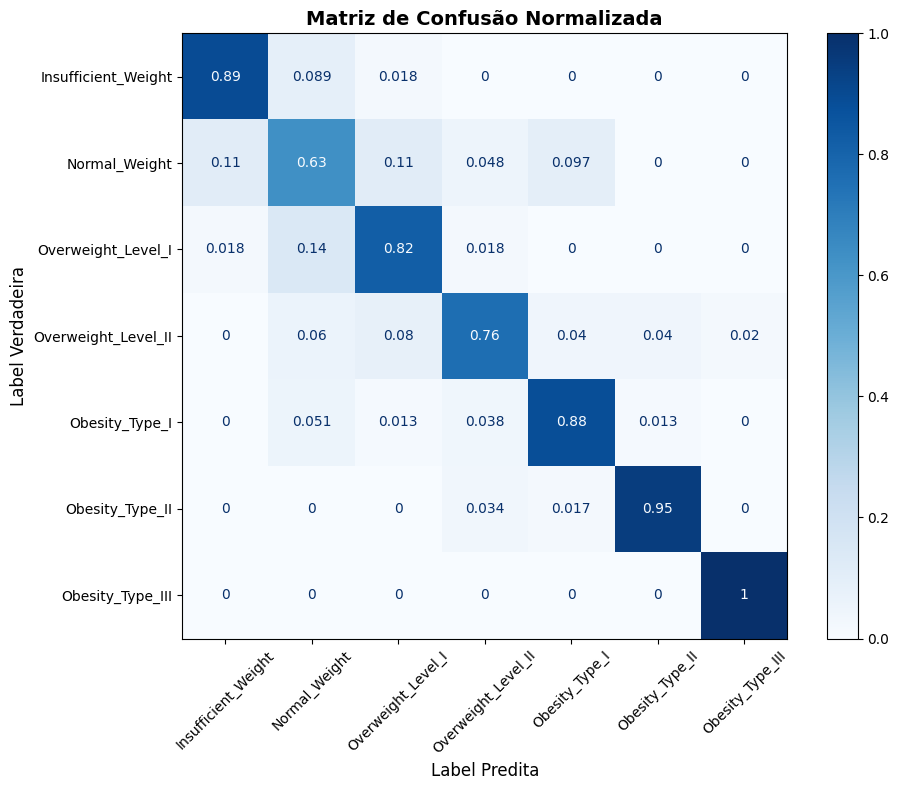


Classification Report
                     precision    recall  f1-score   support

Insufficient_Weight       0.86      0.89      0.88        56
      Normal_Weight       0.66      0.63      0.64        62
 Overweight_Level_I       0.78      0.82      0.80        56
Overweight_Level_II       0.81      0.76      0.78        50
     Obesity_Type_I       0.88      0.88      0.88        78
    Obesity_Type_II       0.95      0.95      0.95        58
   Obesity_Type_III       0.98      1.00      0.99        63

           accuracy                           0.85       423
          macro avg       0.85      0.85      0.85       423
       weighted avg       0.85      0.85      0.85       423



In [602]:
roda_modelo(modelo_lgbm)

### XGBoost

In [603]:
from xgboost import XGBClassifier
modelo_xgbclassifier = XGBClassifier(random_state=SEED, eval_metric='mlogloss')


------------------------------ Resultados XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...) ------------------------------

AUC (weighted OvR): 0.9715

Confusion Matrix



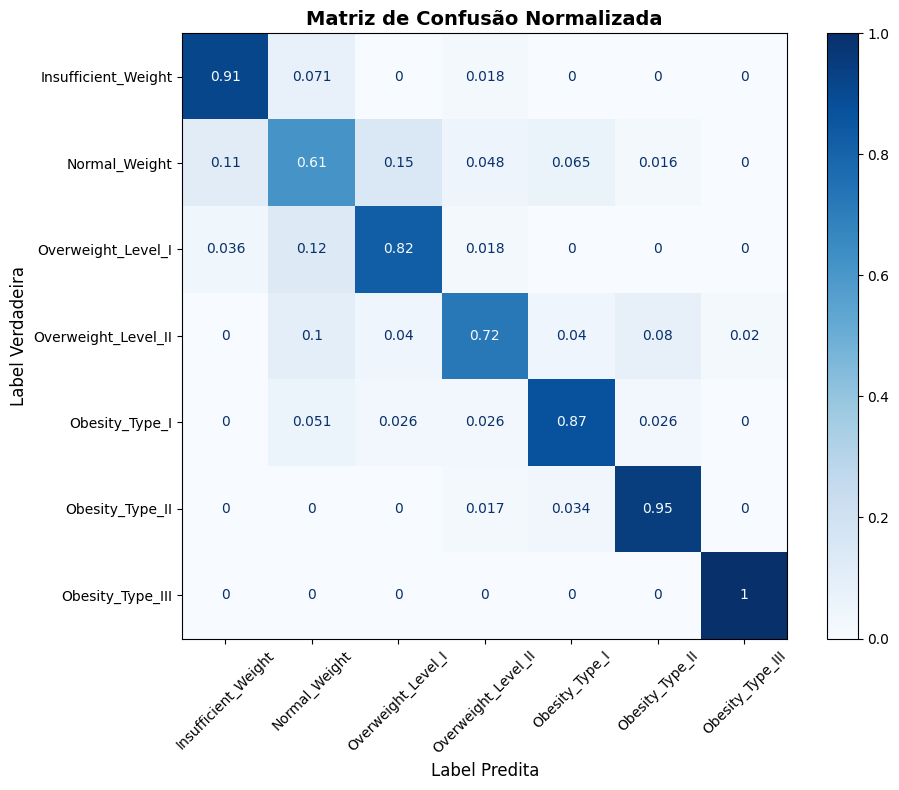


Classification Report
                     precision    recall  f1-score   support

Insufficient_Weight       0.85      0.91      0.88        56
      Normal_Weight       0.66      0.61      0.63        62
 Overweight_Level_I       0.78      0.82      0.80        56
Overweight_Level_II       0.82      0.72      0.77        50
     Obesity_Type_I       0.89      0.87      0.88        78
    Obesity_Type_II       0.89      0.95      0.92        58
   Obesity_Type_III       0.98      1.00      0.99        63

           accuracy                           0.84       423
          macro avg       0.84      0.84      0.84       423
       weighted avg       0.84      0.84      0.84       423



In [604]:
roda_modelo(modelo_xgbclassifier)

### CatBoost

In [605]:
from catboost import CatBoostClassifier
modelo_cat = CatBoostClassifier(random_state=SEED, verbose=0)


------------------------------ Resultados CatBoostClassifier(random_state=42, verbose=0) ------------------------------

AUC (weighted OvR): 0.9734

Confusion Matrix



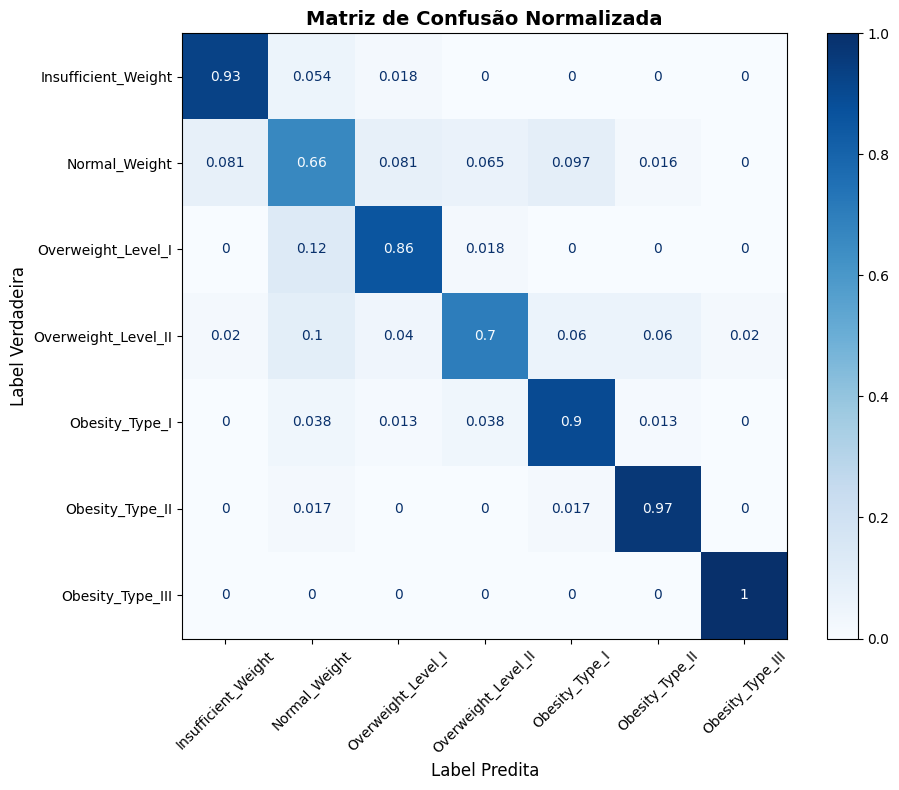


Classification Report
                     precision    recall  f1-score   support

Insufficient_Weight       0.90      0.93      0.91        56
      Normal_Weight       0.68      0.66      0.67        62
 Overweight_Level_I       0.84      0.86      0.85        56
Overweight_Level_II       0.81      0.70      0.75        50
     Obesity_Type_I       0.88      0.90      0.89        78
    Obesity_Type_II       0.92      0.97      0.94        58
   Obesity_Type_III       0.98      1.00      0.99        63

           accuracy                           0.86       423
          macro avg       0.86      0.86      0.86       423
       weighted avg       0.86      0.86      0.86       423



In [606]:
roda_modelo(modelo_cat)

### SVM (RBF)

In [607]:
from sklearn.svm import SVC
modelo_svm = SVC(kernel='rbf', probability=True, random_state=SEED)


------------------------------ Resultados SVC(probability=True, random_state=42) ------------------------------

AUC (weighted OvR): 0.9200

Confusion Matrix



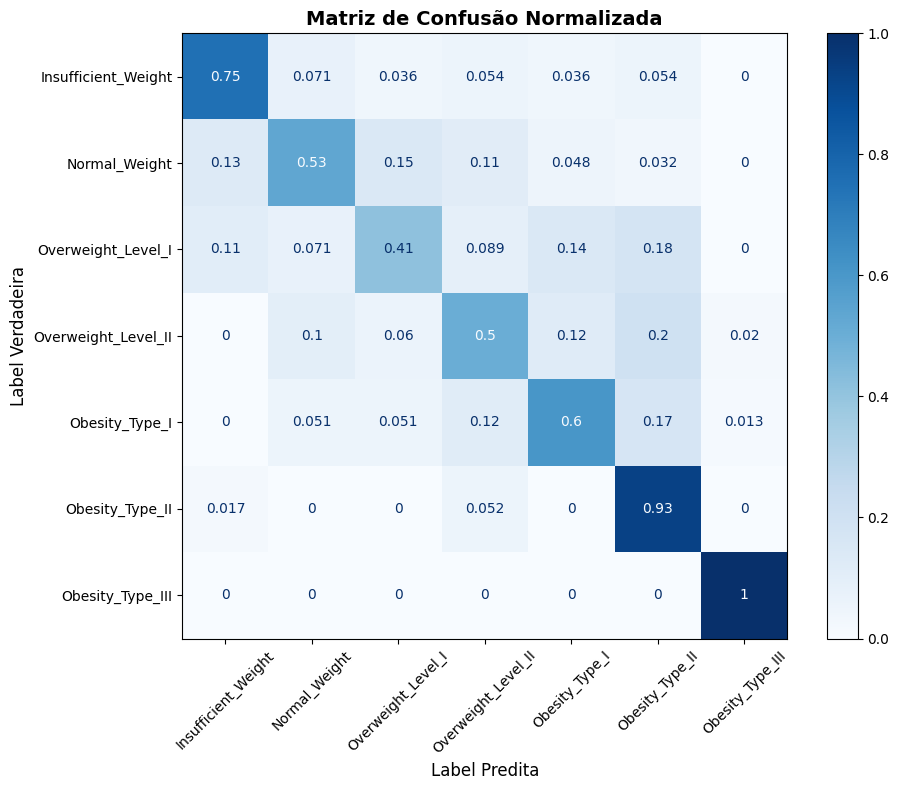


Classification Report
                     precision    recall  f1-score   support

Insufficient_Weight       0.74      0.75      0.74        56
      Normal_Weight       0.66      0.53      0.59        62
 Overweight_Level_I       0.56      0.41      0.47        56
Overweight_Level_II       0.48      0.50      0.49        50
     Obesity_Type_I       0.71      0.60      0.65        78
    Obesity_Type_II       0.59      0.93      0.72        58
   Obesity_Type_III       0.97      1.00      0.98        63

           accuracy                           0.68       423
          macro avg       0.67      0.68      0.66       423
       weighted avg       0.68      0.68      0.67       423



In [608]:
roda_modelo(modelo_svm)

## 6.3 Modelo Final — Voting Classifier

Combinamos os três melhores modelos individuais (Random Forest, CatBoost e LightGBM)
em um ensemble de votação suave (`voting='soft'`), que pondera as probabilidades
preditas por cada modelo para determinar a classe final.


------------------------------ Resultados VotingClassifier(estimators=[('xg',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='mlogloss',
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_co...
                             

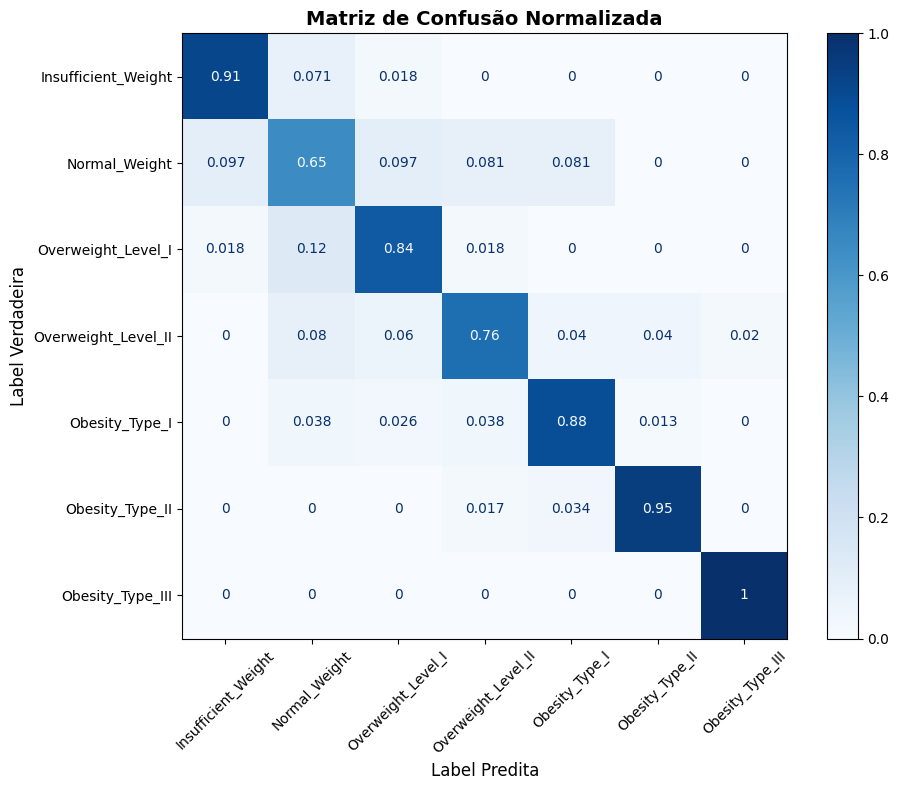


Classification Report
                     precision    recall  f1-score   support

Insufficient_Weight       0.88      0.91      0.89        56
      Normal_Weight       0.69      0.65      0.67        62
 Overweight_Level_I       0.80      0.84      0.82        56
Overweight_Level_II       0.79      0.76      0.78        50
     Obesity_Type_I       0.88      0.88      0.88        78
    Obesity_Type_II       0.95      0.95      0.95        58
   Obesity_Type_III       0.98      1.00      0.99        63

           accuracy                           0.86       423
          macro avg       0.85      0.86      0.85       423
       weighted avg       0.86      0.86      0.86       423



In [609]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(
    estimators=[
       ('xg', XGBClassifier(random_state=SEED, eval_metric='mlogloss')),
        # ('rf',   RandomForestClassifier(min_samples_split=5, random_state=SEED)),
        ('cat',  CatBoostClassifier(random_state=SEED, verbose=0)),
        ('lgbm', LGBMClassifier(verbose=-1))
    ],
    voting='soft'  # pondera as probabilidades de cada modelo
)
roda_modelo(voting)

## 6.4 Comparativo Geral dos Modelos

Consolidamos acurácia e AUC de todos os modelos treinados para facilitar
a comparação e justificar a escolha do modelo final.

In [610]:
modelos = {
    'Logistic Regression':  modelo_logistico,
    'Decision Tree':        modelo_tree,
    'Random Forest':        modelo_forest,
    'Gradient Boosting':    modelo_xgb,
    'LGBM':                 modelo_lgbm,
    'XGBoost':              modelo_xgbclassifier,
    'CatBoost':             modelo_cat,
    'SVM':                  modelo_svm,
    'Voting (RF+Cat+LGBM)': voting
}

resultados = {}
for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    predicao = modelo.predict(X_test)
    prob     = modelo.predict_proba(X_test)
    acc      = accuracy_score(y_test, predicao)
    auc      = roc_auc_score(y_test, prob, multi_class='ovr', average='weighted')
    resultados[nome] = {'acuracia': round(acc * 100, 1), 'auc': round(auc, 4)}

print(f'{'Modelo':<25} {'Acurácia':>10} {'AUC':>8}')
print('-' * 45)
for nome, r in sorted(resultados.items(), key=lambda x: x[1]['acuracia'], reverse=True):
    print(f'{nome:<25} {r["acuracia"]:>9.1f}% {r["auc"]:>8.4f}')

Modelo                      Acurácia      AUC
---------------------------------------------
CatBoost                       86.3%   0.9734
Voting (RF+Cat+LGBM)           85.8%   0.9742
LGBM                           85.1%   0.9710
XGBoost                        84.4%   0.9715
Random Forest                  83.2%   0.9724
Gradient Boosting              81.3%   0.9618
Decision Tree                  73.3%   0.8445
SVM                            67.8%   0.9200
Logistic Regression            60.5%   0.8757


In [611]:
predicao_final   = modelo_cat.predict(X_test)
prob_final       = modelo_cat.predict_proba(X_test)
acc_final        = round(accuracy_score(y_test, predicao_final) * 100, 1)
auc_final        = round(roc_auc_score(y_test, prob_final, multi_class='ovr', average='weighted'), 4)
cm_final         = confusion_matrix(y_test, predicao_final, normalize='true')
n_registros      = len(df)

---
# 7. Deploy — Exportação do Modelo

Serializamos a pipeline e o modelo final em um único arquivo `.pkl`
para uso na aplicação Streamlit.

> **Importante:** a pipeline e o modelo são salvos juntos para garantir
> que as mesmas transformações aplicadas no treino sejam reproduzidas na predição.

In [612]:
import joblib

In [614]:
# Salvando pipeline e modelo em um único artefato
joblib.dump({
    'pipeline':    pipeline,
    'modelo':      modelo_cat,
    'acuracia':    acc_final,
    'auc':         auc_final,
    'matriz':      cm_final,
    'n_registros': n_registros,
    'classes':     CLASSES
}, 'obesidade.pkl')

['obesidade.pkl']